# Loading data and importing important librabries


In [109]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import  train_test_split
from sklearn.linear_model import ElasticNet, HuberRegressor,LinearRegression,Ridge,Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    ExtraTreesRegressor,
    RandomForestRegressor,
)
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
import pandas as pd

df = pd.read_csv("autos.csv.zip")   
df# just give the zip file name

,index,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,...,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen
0,0,2016-03-24 11:52:17,Golf_3_1.6,privat,Angebot,480,test,NaN,1993,manuell,...,golf,150000,0,benzin,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,1,2016-03-24 10:58:45,A5_Sportback_2.7_Tdi,privat,Angebot,18300,test,coupe,2011,manuell,...,NaN,125000,5,diesel,audi,ja,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2,2016-03-14 12:52:21,"Jeep_Grand_Cherokee_""Overland""",privat,Angebot,9800,test,suv,2004,automatik,...,grand,125000,8,diesel,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,3,2016-03-17 16:54:04,GOLF_4_1_4__3TÜRER,privat,Angebot,1500,test,kleinwagen,2001,manuell,...,golf,150000,6,benzin,volkswagen,nein,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,4,2016-03-31 17:25:20,Skoda_Fabia_1.4_TDI_PD_Classic,privat,Angebot,3600,test,kleinwagen,2008,manuell,...,fabia,90000,7,diesel,skoda,nein,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371523,371523,2016-03-14 17:48:27,Suche_t4___vito_ab_6_sitze,privat,Angebot,2200,test,NaN,2005,NaN,...,NaN,20000,1,NaN,sonstige_autos,NaN,2016-03-14 00:00:00,0,39576,2016-04-06 00:46:52
371524,371524,2016-03-05 19:56:21,Smart_smart_leistungssteigerung_100ps,privat,Angebot,1199,test,cabrio,2000,automatik,...,fortwo,125000,3,benzin,smart,nein,2016-03-05 00:00:00,0,26135,2016-03-11 18:17:12
371525,371525,2016-03-19 18:57:12,Volkswagen_Multivan_T4_TDI_7DC_UY2,privat,Angebot,9200,test,bus,1996,manuell,...,transporter,150000,3,diesel,volkswagen,nein,2016-03-19 00:00:00,0,87439,2016-04-07 07:15:26
371526,371526,2016-03-20 19:41:08,VW_Golf_Kombi_1_9l_TDI,privat,Angebot,3400,test,kombi,2002,manuell,...,golf,150000,6,diesel,volkswagen,NaN,2016-03-20 00:00:00,0,40764,2016-03-24 12:45:21


In [111]:
df.head()

,index,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,...,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen
0,0,2016-03-24 11:52:17,Golf_3_1.6,privat,Angebot,480,test,NaN,1993,manuell,...,golf,150000,0,benzin,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,1,2016-03-24 10:58:45,A5_Sportback_2.7_Tdi,privat,Angebot,18300,test,coupe,2011,manuell,...,NaN,125000,5,diesel,audi,ja,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2,2016-03-14 12:52:21,"Jeep_Grand_Cherokee_""Overland""",privat,Angebot,9800,test,suv,2004,automatik,...,grand,125000,8,diesel,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,3,2016-03-17 16:54:04,GOLF_4_1_4__3TÜRER,privat,Angebot,1500,test,kleinwagen,2001,manuell,...,golf,150000,6,benzin,volkswagen,nein,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,4,2016-03-31 17:25:20,Skoda_Fabia_1.4_TDI_PD_Classic,privat,Angebot,3600,test,kleinwagen,2008,manuell,...,fabia,90000,7,diesel,skoda,nein,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


In [112]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 371528 entries, 0 to 371527
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   index                371528 non-null  int64
 1   dateCrawled          371528 non-null  str  
 2   name                 371528 non-null  str  
 3   seller               371528 non-null  str  
 4   offerType            371528 non-null  str  
 5   price                371528 non-null  int64
 6   abtest               371528 non-null  str  
 7   vehicleType          333659 non-null  str  
 8   yearOfRegistration   371528 non-null  int64
 9   gearbox              351319 non-null  str  
 10  powerPS              371528 non-null  int64
 11  model                351044 non-null  str  
 12  kilometer            371528 non-null  int64
 13  monthOfRegistration  371528 non-null  int64
 14  fuelType             338142 non-null  str  
 15  brand                371528 non-null  str  
 16  notRepairedDa

In [113]:
df.describe()

,index,price,yearOfRegistration,powerPS,kilometer,monthOfRegistration,nrOfPictures,postalCode
count,371528.000000,3.715280e+05,371528.000000,371528.000000,371528.000000,371528.000000,371528.0,371528.00000
mean,185763.500000,1.729514e+04,2004.577997,115.549477,125618.688228,5.734445,0.0,50820.66764
std,107251.039743,3.587954e+06,92.866598,192.139578,40112.337051,3.712412,0.0,25799.08247
min,0.000000,0.000000e+00,1000.000000,0.000000,5000.000000,0.000000,0.0,1067.00000
25%,92881.750000,1.150000e+03,1999.000000,70.000000,125000.000000,3.000000,0.0,30459.00000
50%,185763.500000,2.950000e+03,2003.000000,105.000000,150000.000000,6.000000,0.0,49610.00000
75%,278645.250000,7.200000e+03,2008.000000,150.000000,150000.000000,9.000000,0.0,71546.00000
max,371527.000000,2.147484e+09,9999.000000,20000.000000,150000.000000,12.000000,0.0,99998.00000


In [114]:
df.describe(include='str')

,dateCrawled,name,seller,offerType,abtest,vehicleType,gearbox,model,fuelType,brand,notRepairedDamage,dateCreated,lastSeen
count,371528,371528,371528,371528,371528,333659,351319,351044,338142,371528,299468,371528,371528
unique,280500,233531,2,2,2,8,2,251,7,40,2,114,182806
top,2016-03-24 14:49:47,Ford_Fiesta,privat,Angebot,test,limousine,manuell,golf,benzin,volkswagen,nein,2016-04-03 00:00:00,2016-04-07 06:45:59
freq,7,657,371525,371516,192585,95894,274214,30070,223857,79640,263182,14450,17


In [115]:
df.columns

Index(['index', 'dateCrawled', 'name', 'seller', 'offerType', 'price',
       'abtest', 'vehicleType', 'yearOfRegistration', 'gearbox', 'powerPS',
       'model', 'kilometer', 'monthOfRegistration', 'fuelType', 'brand',
       'notRepairedDamage', 'dateCreated', 'nrOfPictures', 'postalCode',
       'lastSeen'],
      dtype='str')

In [116]:
df.drop(columns=['index','postalCode',],inplace=True)

In [117]:
df.columns

Index(['dateCrawled', 'name', 'seller', 'offerType', 'price', 'abtest',
       'vehicleType', 'yearOfRegistration', 'gearbox', 'powerPS', 'model',
       'kilometer', 'monthOfRegistration', 'fuelType', 'brand',
       'notRepairedDamage', 'dateCreated', 'nrOfPictures', 'lastSeen'],
      dtype='str')

In [118]:
df.isna().sum()

dateCrawled                0
name                       0
seller                     0
offerType                  0
price                      0
abtest                     0
vehicleType            37869
yearOfRegistration         0
gearbox                20209
powerPS                    0
model                  20484
kilometer                  0
monthOfRegistration        0
fuelType               33386
brand                      0
notRepairedDamage      72060
dateCreated                0
nrOfPictures               0
lastSeen                   0
dtype: int64

In [119]:
df.dropna(inplace=True)

In [120]:
df.duplicated().sum()

np.int64(5)

In [121]:
df.drop_duplicates(inplace=True)

# Overview

In [122]:
df['dateCrawled'].head()

3    2016-03-17 16:54:04
4    2016-03-31 17:25:20
5    2016-04-04 17:36:23
6    2016-04-01 20:48:51
7    2016-03-21 18:54:38
Name: dateCrawled, dtype: str

In [123]:
df['dateCrawled'].unique()

<ArrowStringArray>
['2016-03-17 16:54:04', '2016-03-31 17:25:20', '2016-04-04 17:36:23',
 '2016-04-01 20:48:51', '2016-03-21 18:54:38', '2016-03-26 19:54:18',
 '2016-04-07 10:06:22', '2016-03-21 12:57:01', '2016-03-20 10:25:19',
 '2016-03-23 15:48:05',
 ...
 '2016-04-01 01:55:58', '2016-03-20 18:47:59', '2016-04-02 16:43:27',
 '2016-03-06 21:11:23', '2016-04-04 09:57:12', '2016-03-28 13:48:07',
 '2016-03-19 19:53:49', '2016-03-27 20:36:20', '2016-03-19 18:57:12',
 '2016-03-07 19:39:19']
Length: 213628, dtype: str

In [124]:
df['dateCrawled'] = pd.to_datetime(df['dateCrawled'], errors='coerce').dt.strftime('%Y-%m')

In [125]:
df['dateCrawled'].head()

3    2016-03
4    2016-03
5    2016-04
6    2016-04
7    2016-03
Name: dateCrawled, dtype: str

In [126]:
df['dateCrawled'].unique()

<ArrowStringArray>
['2016-03', '2016-04']
Length: 2, dtype: str

In [127]:
df['name'].head()

3                                   GOLF_4_1_4__3TÜRER
4                       Skoda_Fabia_1.4_TDI_PD_Classic
5    BMW_316i___e36_Limousine___Bastlerfahrzeug__Ex...
6                          Peugeot_206_CC_110_Platinum
7                         VW_Derby_Bj_80__Scheunenfund
Name: name, dtype: str

In [128]:
df['name'].nunique()

150361

In [129]:
df['seller'].head()

3    privat
4    privat
5    privat
6    privat
7    privat
Name: seller, dtype: str

In [130]:
df['seller'].unique()

<ArrowStringArray>
['privat', 'gewerblich']
Length: 2, dtype: str

In [131]:
df['seller'].value_counts()

seller
privat        260949
gewerblich         2
Name: count, dtype: int64

In [132]:
df['offerType'].head()

3    Angebot
4    Angebot
5    Angebot
6    Angebot
7    Angebot
Name: offerType, dtype: str

In [133]:
df['offerType'].unique()

<ArrowStringArray>
['Angebot', 'Gesuch']
Length: 2, dtype: str

In [134]:
df['offerType'].value_counts()

offerType
Angebot    260947
Gesuch          4
Name: count, dtype: int64

In [135]:
df['abtest'].head()

3    test
4    test
5    test
6    test
7    test
Name: abtest, dtype: str

In [136]:
df['abtest'].unique()

<ArrowStringArray>
['test', 'control']
Length: 2, dtype: str

In [137]:
df['abtest'].value_counts()

abtest
test       135515
control    125436
Name: count, dtype: int64

In [138]:
df['vehicleType'].head()

3    kleinwagen
4    kleinwagen
5     limousine
6        cabrio
7     limousine
Name: vehicleType, dtype: str

In [139]:
df['vehicleType'].unique()

<ArrowStringArray>
['kleinwagen', 'limousine', 'cabrio', 'kombi', 'suv', 'bus', 'coupe',
 'andere']
Length: 8, dtype: str

In [140]:
df['vehicleType'].value_counts()

vehicleType
limousine     76394
kleinwagen    59102
kombi         53440
bus           24963
cabrio        18549
coupe         14649
suv           12082
andere         1772
Name: count, dtype: int64

In [141]:
df['vehicleType'].isna().sum()

np.int64(0)

In [142]:
df['yearOfRegistration'].head()

3    2001
4    2008
5    1995
6    2004
7    1980
Name: yearOfRegistration, dtype: int64

In [143]:
df['yearOfRegistration'].unique()

array([2001, 2008, 1995, 2004, 1980, 2005, 2011, 2007, 2009, 2002, 1997,
       1990, 1981, 2003, 1984, 1999, 1998, 2012, 2014, 2006, 2010, 2000,
       1993, 2013, 1994, 1991, 1996, 1989, 2015, 1968, 1992, 1983, 1959,
       1973, 1969, 1971, 1987, 1988, 1967, 2016, 1986, 1985, 1965, 1945,
       1974, 1979, 1982, 1978, 1976, 1972, 1977, 1966, 1975, 1970, 1937,
       1963, 1936, 1954, 1961, 1962, 1960, 1951, 1964, 1953, 1957, 1958,
       1956, 2017, 1950, 1955, 1948, 1932, 1952, 1931, 2018, 1949, 1942,
       1910, 1923, 1930, 1943, 1938, 1941, 1934, 1919, 1939, 1929, 1933,
       1947])

In [144]:
df['yearOfRegistration'].min()

np.int64(1910)

In [145]:
len(df[df['yearOfRegistration']==df['yearOfRegistration'].min()])

3

In [146]:
df['yearOfRegistration'].max()

np.int64(2018)

In [147]:
len(df[df['yearOfRegistration']==df['yearOfRegistration'].max()])

3

In [148]:
df['gearbox'].head()

3    manuell
4    manuell
5    manuell
6    manuell
7    manuell
Name: gearbox, dtype: str

In [149]:
df['gearbox'].unique()

<ArrowStringArray>
['manuell', 'automatik']
Length: 2, dtype: str

In [150]:
df['gearbox'].value_counts()

gearbox
manuell      200056
automatik     60895
Name: count, dtype: int64

In [151]:
df['gearbox'].isna().sum()

np.int64(0)

In [152]:
df['powerPS'].head()

3     75
4     69
5    102
6    109
7     50
Name: powerPS, dtype: int64

In [153]:
df['powerPS'].describe()

count    260951.000000
mean        126.331687
std         145.278713
min           0.000000
25%          78.000000
50%         116.000000
75%         150.000000
max       20000.000000
Name: powerPS, dtype: float64

In [154]:
df['model'].head()

3       golf
4      fabia
5        3er
6    2_reihe
7     andere
Name: model, dtype: str

In [155]:
df['model'].unique()

<ArrowStringArray>
[           'golf',           'fabia',             '3er',         '2_reihe',
          'andere',         '3_reihe',          'passat',          'navara',
          'twingo',           'c_max',
 ...
            'move',         'materia',          'kalina',          'samara',
      'elefantino',              'i3',      'rangerover',         'serie_3',
           'kappa', 'discovery_sport']
Length: 250, dtype: str

In [156]:
df['model'].value_counts()

model
golf               20957
andere             20293
3er                15645
polo                8828
corsa               8267
                   ...  
i3                     5
rangerover             4
samara                 3
serie_3                3
discovery_sport        1
Name: count, Length: 250, dtype: int64

In [157]:
df['kilometer'].head()

3    150000
4     90000
5    150000
6    150000
7     40000
Name: kilometer, dtype: int64

In [158]:
df['kilometer'].describe()

count    260951.000000
mean     124059.114546
std       39847.775786
min        5000.000000
25%      100000.000000
50%      150000.000000
75%      150000.000000
max      150000.000000
Name: kilometer, dtype: float64

In [159]:
df['monthOfRegistration'].head()

3     6
4     7
5    10
6     8
7     7
Name: monthOfRegistration, dtype: int64

In [160]:
df['monthOfRegistration'].unique()

array([ 6,  7, 10,  8, 12,  3,  2,  1,  4,  5,  9, 11,  0])

In [161]:
df['fuelType'].head()

3    benzin
4    diesel
5    benzin
6    benzin
7    benzin
Name: fuelType, dtype: str

In [162]:
df['fuelType'].unique()

<ArrowStringArray>
['benzin', 'diesel', 'lpg', 'andere', 'hybrid', 'cng', 'elektro']
Length: 7, dtype: str

In [163]:
df['fuelType'].value_counts()

fuelType
benzin     169239
diesel      86972
lpg          3937
cng           460
hybrid        213
andere         73
elektro        57
Name: count, dtype: int64

In [164]:
df['brand'].unique()

<ArrowStringArray>
[   'volkswagen',         'skoda',           'bmw',       'peugeot',
         'mazda',        'nissan',       'renault',          'ford',
 'mercedes_benz',          'seat',         'honda',          'fiat',
          'mini',          'opel',         'smart',          'audi',
    'alfa_romeo',        'subaru',    'mitsubishi',       'hyundai',
         'volvo',        'lancia',       'porsche',       'citroen',
        'toyota',           'kia',     'chevrolet',         'dacia',
        'suzuki',      'daihatsu',      'chrysler',        'jaguar',
         'rover',          'jeep',          'saab',        'daewoo',
    'land_rover',       'trabant',          'lada']
Length: 39, dtype: str

In [165]:
df['brand'].value_counts()

brand
volkswagen       54192
bmw              30331
mercedes_benz    26904
opel             26390
audi             24772
ford             17447
renault          11672
peugeot           7851
fiat              6365
seat              5017
skoda             4536
mazda             4039
toyota            3703
citroen           3690
nissan            3594
smart             3352
mini              2877
hyundai           2787
volvo             2588
mitsubishi        2075
kia               1970
honda             1946
porsche           1866
alfa_romeo        1704
suzuki            1682
chevrolet         1348
chrysler          1025
dacia              723
land_rover         635
jeep               616
subaru             550
daihatsu           520
jaguar             487
saab               421
daewoo             337
lancia             320
rover              262
trabant            211
lada               146
Name: count, dtype: int64

In [166]:
df['notRepairedDamage'].head()

3    nein
4    nein
5      ja
6    nein
7    nein
Name: notRepairedDamage, dtype: str

In [167]:
df['notRepairedDamage'].unique()

<ArrowStringArray>
['nein', 'ja']
Length: 2, dtype: str

In [168]:
df['notRepairedDamage'].value_counts()

notRepairedDamage
nein    232942
ja       28009
Name: count, dtype: int64

In [169]:
df['dateCreated'] = pd.to_datetime(df['dateCreated'], errors='coerce').dt.strftime('%Y-%m')

In [170]:
df['dateCreated'].unique()

<ArrowStringArray>
['2016-03', '2016-04', '2016-02', '2016-01', '2015-03', '2015-11', '2015-12',
 '2015-09', '2015-08', '2015-10']
Length: 10, dtype: str

In [171]:
df['nrOfPictures'].head()

3    0
4    0
5    0
6    0
7    0
Name: nrOfPictures, dtype: int64

In [172]:
df['nrOfPictures'].unique()

array([0])

In [173]:
df['lastSeen'].head()

3    2016-03-17 17:40:17
4    2016-04-06 10:17:21
5    2016-04-06 19:17:07
6    2016-04-05 18:18:39
7    2016-03-25 16:47:58
Name: lastSeen, dtype: str

In [174]:
df['lastSeen'] = pd.to_datetime(df['lastSeen'], errors='coerce').dt.strftime('%Y-%m')

In [175]:
df['lastSeen'].unique()

<ArrowStringArray>
['2016-03', '2016-04']
Length: 2, dtype: str

## Inisghts of Overview
- `dateCrawled`, `lastSeen` and `dateCreated` do not contain any useful information for model. They contain only 2 unique values.
- `name` does not contain any information which can be useful for model. I contain around 230,000 unique values
- `seller` only contain three values other than `private` so its better to drop it
- `offerType` contain only 12 value other than `angeboot` so its better to drop it
- `yearOfRegistration` and `powerPS` contain many queer value whcih are needed to be removed 
- `monthOfRegistration` and `nrOfPictures` do not contain any useful information for model so its better to drop it


In [176]:
df.drop(columns=['dateCrawled','lastSeen','dateCreated',
                'name','seller','offerType',
                'monthOfRegistration','nrOfPictures'],inplace=True)

In [177]:
df.columns

Index(['price', 'abtest', 'vehicleType', 'yearOfRegistration', 'gearbox',
       'powerPS', 'model', 'kilometer', 'fuelType', 'brand',
       'notRepairedDamage'],
      dtype='str')

# EDA  (Exploratery Data Analysis)

In [178]:
df['abtest']

3            test
4            test
5            test
6            test
7            test
           ...   
371520    control
371521    control
371524       test
371525       test
371527    control
Name: abtest, Length: 260951, dtype: str

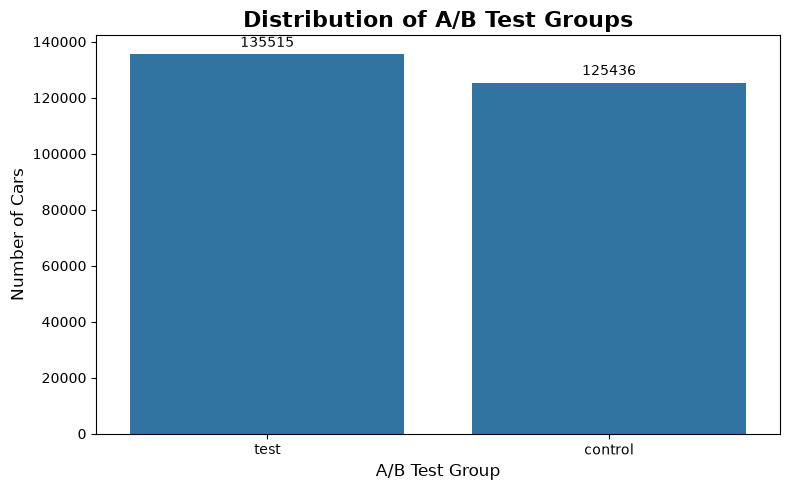

In [179]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(data=df, x='abtest')

plt.title('Distribution of A/B Test Groups', fontsize=16, fontweight='bold')
plt.xlabel('A/B Test Group', fontsize=12)
plt.ylabel('Number of Cars', fontsize=12)

# Add counts on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.tight_layout()
plt.show()

An A/B test divides users/items into two groups:

A → Control group                                                                                       
B → Test/experimental group

The goal is to compare whether changing something produces different results.

In [180]:
df.groupby('abtest')['price'].mean().round(2)

abtest
control    7892.22
test       8501.66
Name: price, dtype: float64

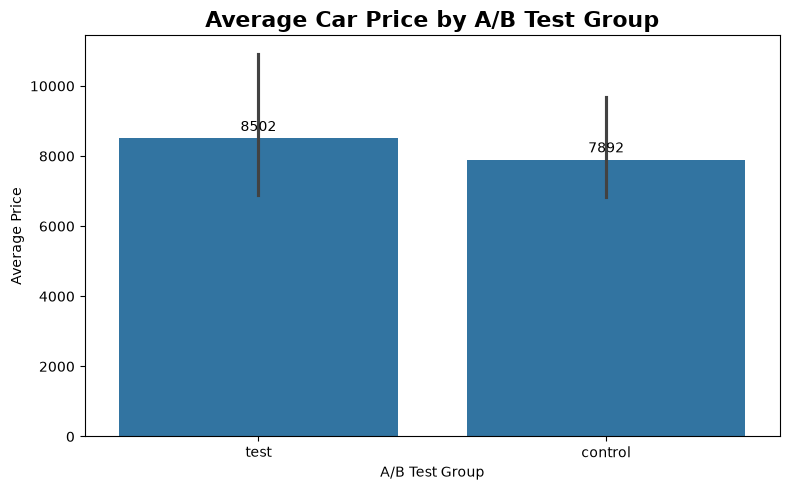

In [181]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(data=df, x='abtest', y='price', estimator='mean')

plt.title('Average Car Price by A/B Test Group', fontsize=16, fontweight='bold')
plt.xlabel('A/B Test Group')
plt.ylabel('Average Price')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()

- This graph shows that car with test has slightly higher price than other ones


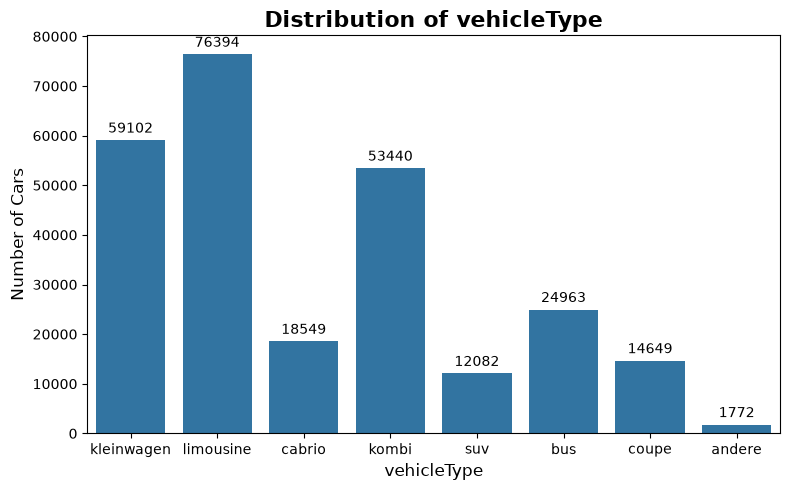

In [182]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(data=df, x='vehicleType')

plt.title('Distribution of vehicleType', fontsize=16, fontweight='bold')
plt.xlabel('vehicleType', fontsize=12)
plt.ylabel('Number of Cars', fontsize=12)

# Add counts on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.tight_layout()
plt.show()

In [183]:
df.groupby('vehicleType')['price'].mean().round(2)

vehicleType
andere         4399.40
bus            7465.59
cabrio        11198.53
coupe         21207.11
kleinwagen     3111.66
kombi          8488.40
limousine      8156.00
suv           13982.21
Name: price, dtype: float64

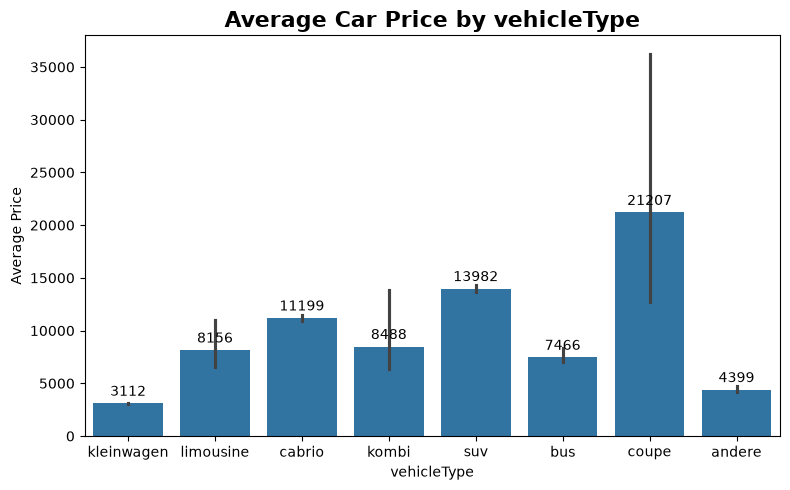

In [184]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(data=df, x='vehicleType', y='price', estimator='mean')

plt.title('Average Car Price by vehicleType', fontsize=16, fontweight='bold')
plt.xlabel('vehicleType')
plt.ylabel('Average Price')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()

- This graph shows that `coupe` has highest average price and `kleinwagen` has lowest average price 

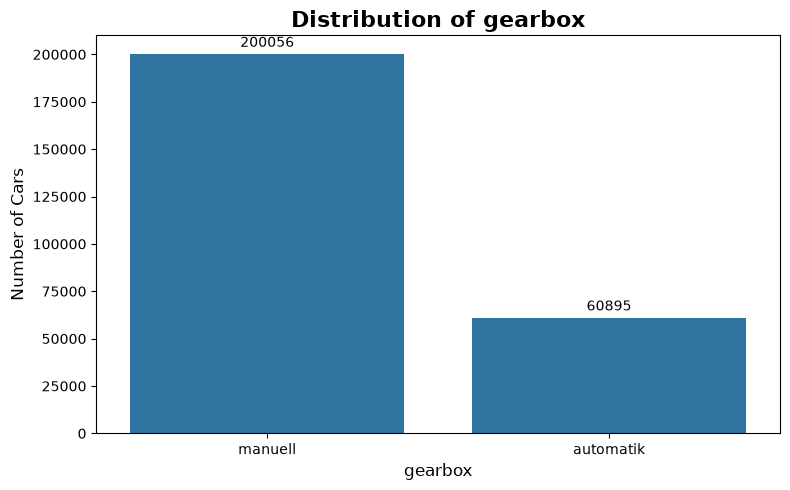

In [185]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(data=df, x='gearbox')

plt.title('Distribution of gearbox', fontsize=16, fontweight='bold')
plt.xlabel('gearbox', fontsize=12)
plt.ylabel('Number of Cars', fontsize=12)

# Add counts on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.tight_layout()
plt.show()

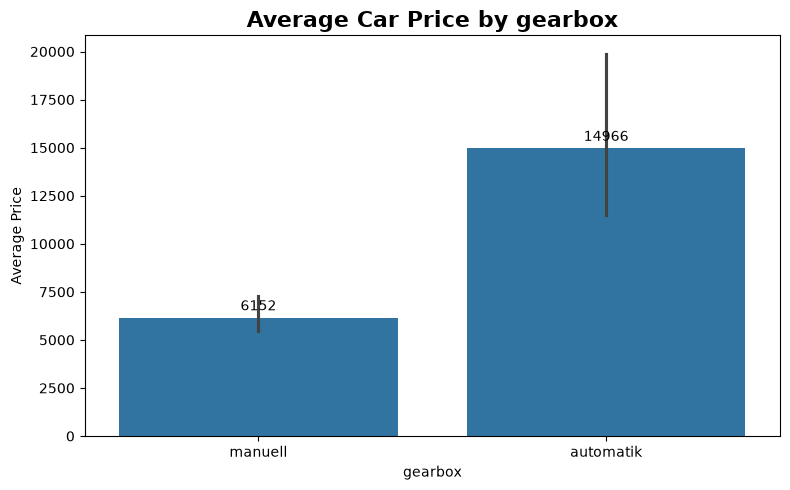

In [186]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(data=df, x='gearbox', y='price', estimator='mean')

plt.title('Average Car Price by gearbox', fontsize=16, fontweight='bold')
plt.xlabel('gearbox')
plt.ylabel('Average Price')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()

- This graph shows that `automatik` has higher average price than `manuell`

In [187]:
df['model'].nunique()

250

In [188]:
df['model'].value_counts().tail(150)

model
almera             415
c3                 406
s_max              403
espace             400
c5                 399
                  ... 
i3                   5
rangerover           4
samara               3
serie_3              3
discovery_sport      1
Name: count, Length: 150, dtype: int64

In [189]:
model_counts = df['model'].value_counts()

df['model'] = df['model'].where(
    df['model'].map(model_counts) >= 100,
    'other'
)

In [190]:
avg_price = (
    df[df['model'] != 'other']
    .groupby('model')['price']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

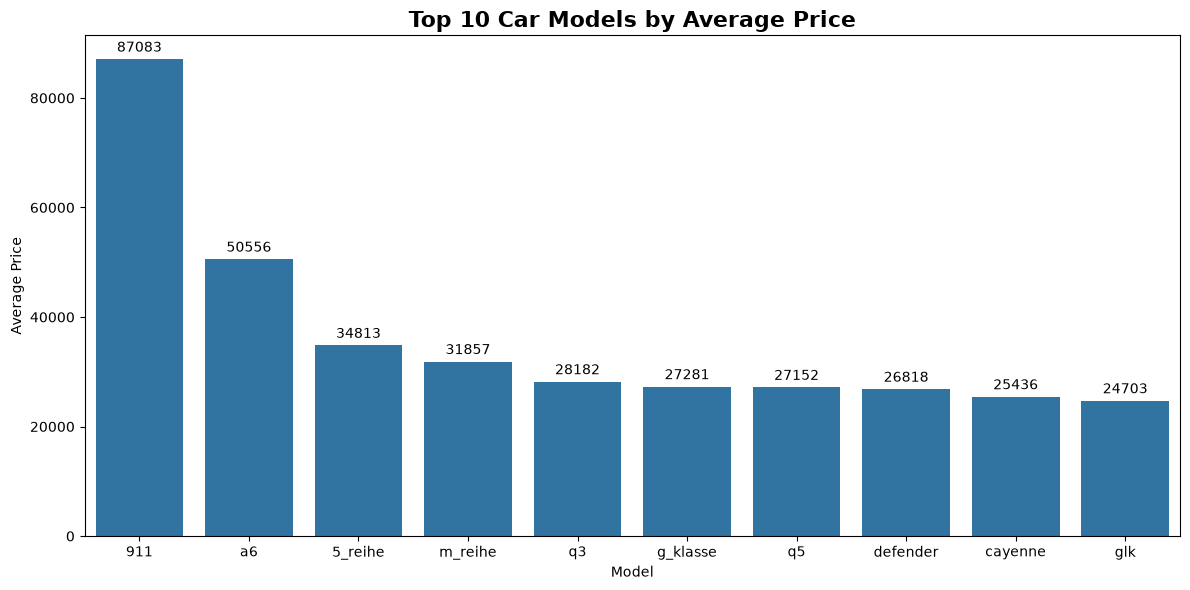

In [191]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x=avg_price.index,
    y=avg_price.values
)

plt.title('Top 10 Car Models by Average Price', fontsize=16, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('Average Price')


for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()

- This graph shows 10 highest average price car model_counts, and `911` is highest in them

In [192]:
df['kilometer'].max()

np.int64(150000)

In [193]:
df[['kilometer', 'price']].corr()

,kilometer,price
kilometer,1.000000,-0.013932
price,-0.013932,1.000000


In [194]:
df['km_group'] = pd.cut(
    df['kilometer'],
    bins=[0, 50000, 100000, 150000,],
    labels=['0-50k', '50k-100k', '100k-150k', ]
)

In [195]:
avg_price_km = df.groupby('km_group', observed=True)['price'].mean()

print(avg_price_km)

km_group
0-50k        21596.990449
50k-100k     10354.895869
100k-150k     5932.698448
Name: price, dtype: float64


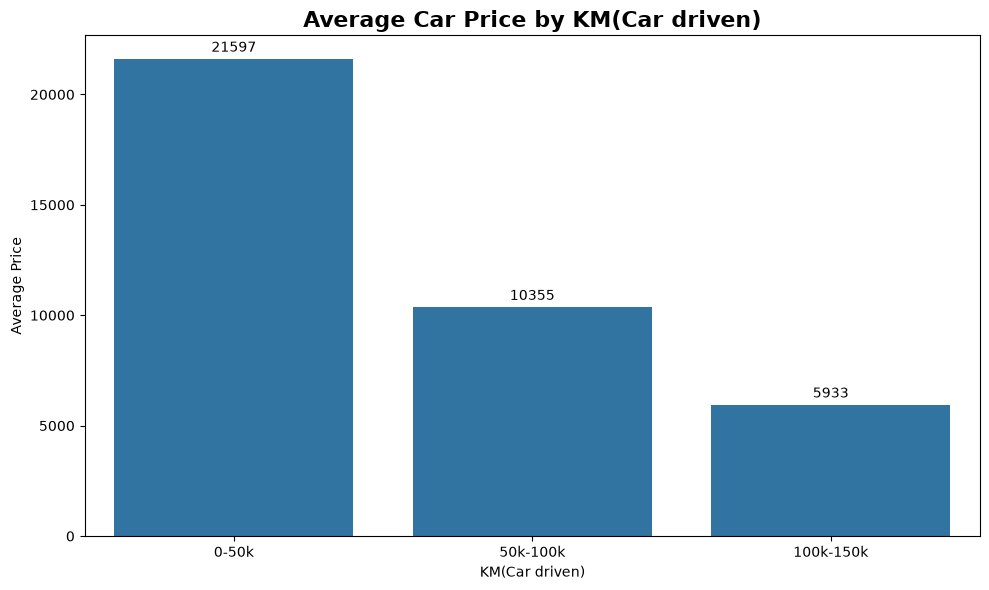

In [196]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=avg_price_km.index,
    y=avg_price_km.values
)

plt.title('Average Car Price by KM(Car driven)', fontsize=16, fontweight='bold')
plt.xlabel('KM(Car driven)')
plt.ylabel('Average Price')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()

- This graph shows less the car driven, more the price is.

In [197]:
df['fuelType'].value_counts()

fuelType
benzin     169239
diesel      86972
lpg          3937
cng           460
hybrid        213
andere         73
elektro        57
Name: count, dtype: int64

In [198]:
model_counts = df['fuelType'].value_counts()

df['fuelType'] = df['fuelType'].where(
    df['fuelType'].map(model_counts) >= 1000,
    'other'
)

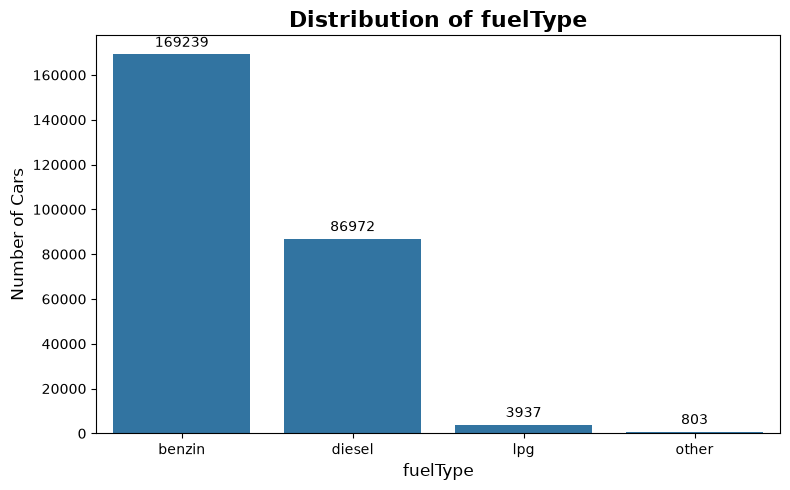

In [199]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(data=df, x='fuelType')

plt.title('Distribution of fuelType', fontsize=16, fontweight='bold')
plt.xlabel('fuelType', fontsize=12)
plt.ylabel('Number of Cars', fontsize=12)

# Add counts on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.tight_layout()
plt.show()

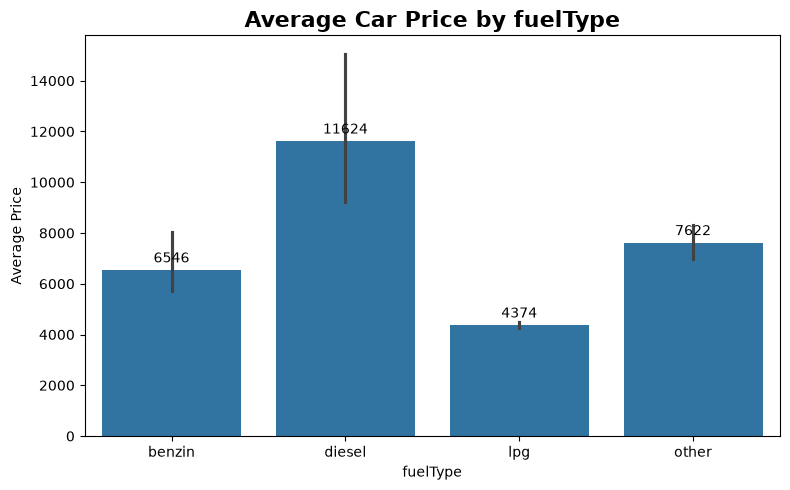

In [200]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(data=df, x='fuelType', y='price', estimator='mean')

plt.title('Average Car Price by fuelType', fontsize=16, fontweight='bold')
plt.xlabel('fuelType')
plt.ylabel('Average Price')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()

- This graph shows that car with `diesel` feul type has highest average value

In [201]:
brand_counts = df['brand'].value_counts()

top_brands = (
    df[df['brand'].isin(brand_counts[brand_counts >= 500].index)]
    .groupby('brand')['price']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

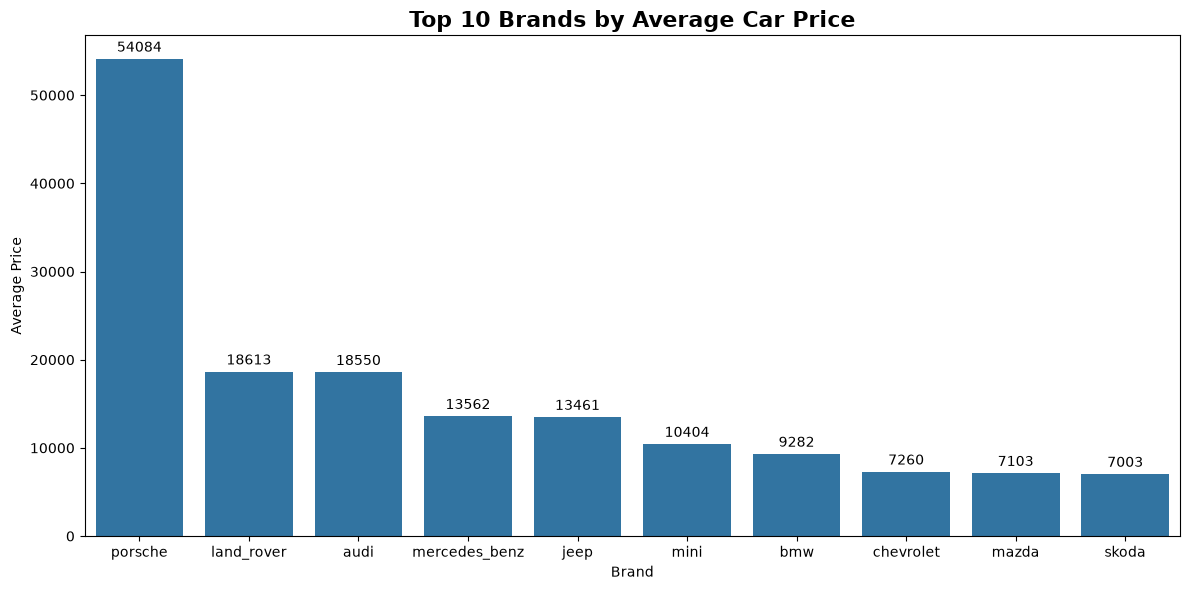

In [202]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x=top_brands.index,
    y=top_brands.values
)

plt.title('Top 10 Brands by Average Car Price', fontsize=16, fontweight='bold')
plt.xlabel('Brand')
plt.ylabel('Average Price')


for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()

- This graph shows that `porsche` has highest average price in car brands

In [203]:
df['notRepairedDamage'].unique()

<ArrowStringArray>
['nein', 'ja']
Length: 2, dtype: str

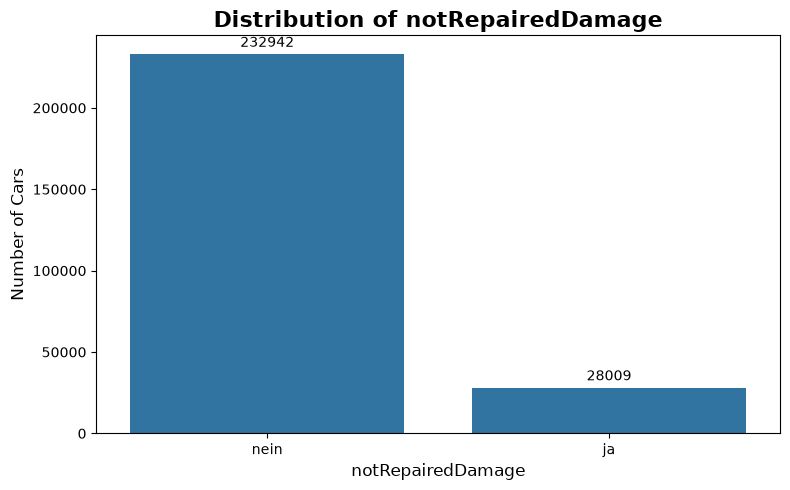

In [204]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(data=df, x='notRepairedDamage')

plt.title('Distribution of notRepairedDamage', fontsize=16, fontweight='bold')
plt.xlabel('notRepairedDamage', fontsize=12)
plt.ylabel('Number of Cars', fontsize=12)

# Add counts on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.tight_layout()
plt.show()

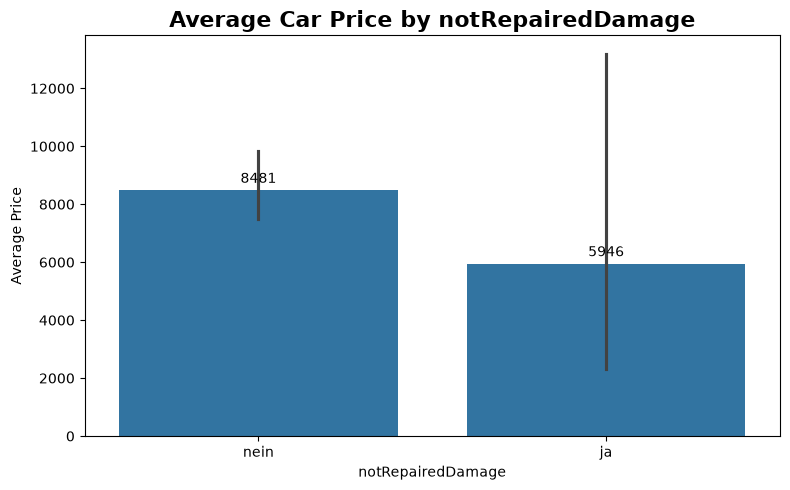

In [205]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(data=df, x='notRepairedDamage', y='price', estimator='mean')

plt.title('Average Car Price by notRepairedDamage', fontsize=16, fontweight='bold')
plt.xlabel('notRepairedDamage')
plt.ylabel('Average Price')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()

- This graph shows cars with no damaged to be remaired has more average price than the cars with damaged to be remaired

In [206]:
print("Price <= 0:", (df['price'] <= 0).sum())
print("Price > 100,000:", (df['price'] > 100000).sum())
print("Price > 500,000:", (df['price'] > 500000).sum())

Price <= 0: 3389
Price > 100,000: 225
Price > 500,000: 29


In [207]:
df['price'].describe()

count    2.609510e+05
mean     8.208710e+03
std      3.433124e+05
min      0.000000e+00
25%      1.500000e+03
50%      3.850000e+03
75%      8.600000e+03
max      1.000000e+08
Name: price, dtype: float64

In [208]:
df[df['price'] > 500000][
    ['price', 'brand', 'model', 'kilometer']
].sort_values('price', ascending=False)

,price,brand,model,kilometer
127820,99999999,audi,a6,5000
139052,99999999,mercedes_benz,andere,150000
251980,99000000,audi,a6,150000
279937,14000500,mercedes_benz,clk,125000
241847,12345678,opel,vectra,150000
287835,12345678,ford,focus,150000
210657,11111111,ford,escort,50000
54295,10000000,mazda,5_reihe,150000
91106,9999999,audi,a4,60000
21467,9999999,porsche,911,50000


In [209]:
def filter_year(df, column, min_year, max_year):
    before = len(df)

    df = df[
        (df[column] >= min_year) &
        (df[column] <= max_year)
    ].copy()

    after = len(df)

    print(f"Rows before: {before}")
    print(f"Rows after: {after}")
    print(f"Rows removed: {before - after}")
    print(f"Data removed: {(before - after) / before * 100:.2f}%")

    return df

In [210]:
df = filter_year(
    df,
    'yearOfRegistration',
    1970,
    2020
)

Rows before: 260951
Rows after: 260277
Rows removed: 674
Data removed: 0.26%


In [211]:
def remove_quantile_outliers(df, column, lower=0.01, upper=0.99):
    lower_bound = df[column].quantile(lower)
    upper_bound = df[column].quantile(upper)

    df_clean = df[
        (df[column] >= lower_bound) &
        (df[column] <= upper_bound)
    ].copy()

    print(f"Column: {column}")
    print(f"Lower bound: {lower_bound}")
    print(f"Upper bound: {upper_bound}")
    print(f"Rows before: {len(df)}")
    print(f"Rows after: {len(df_clean)}")
    print(f"Rows removed: {len(df) - len(df_clean)}")
    print(f"Data removed: {(len(df) - len(df_clean)) / len(df) * 100:.2f}%")

    return df_clean

In [212]:
df = remove_quantile_outliers(
    df,
    'price',
    lower=0,
    upper=0.99
)

Column: price
Lower bound: 0.0
Upper bound: 37950.0
Rows before: 260277
Rows after: 257675
Rows removed: 2602
Data removed: 1.00%


In [213]:
df = remove_quantile_outliers(
    df,
    'powerPS',
    lower=.25,
    upper=0.75
)

Column: powerPS
Lower bound: 77.0
Upper bound: 150.0
Rows before: 257675
Rows after: 131385
Rows removed: 126290
Data removed: 49.01%


# Preprocessing

In [214]:
df.columns

Index(['price', 'abtest', 'vehicleType', 'yearOfRegistration', 'gearbox',
       'powerPS', 'model', 'kilometer', 'fuelType', 'brand',
       'notRepairedDamage', 'km_group'],
      dtype='str')

In [215]:
df['km_group']

5         100k-150k
6         100k-150k
10        100k-150k
11        100k-150k
18        100k-150k
            ...    
371511    100k-150k
371513    100k-150k
371517    100k-150k
371524    100k-150k
371525    100k-150k
Name: km_group, Length: 131385, dtype: category
Categories (3, str): ['0-50k' < '50k-100k' < '100k-150k']

In [216]:
df.drop(columns=['km_group'],inplace=True)

In [217]:
X = df.drop(columns='price')
y = df['price']

In [218]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [219]:
cat_cols = [
    'abtest',
    'vehicleType',
    'gearbox',
    'model',
    'fuelType',
    'brand',
    'notRepairedDamage'
]
num_cols = ['kilometer','yearOfRegistration']

In [220]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), num_cols)
    ]
)

In [221]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

# Model selection 

In [ ]:
models = {
    # Linear models
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'ElasticNet': ElasticNet(),

    # Tree models
    'Decision Tree': DecisionTreeRegressor(),

    'Random Forest': RandomForestRegressor(),

    'Extra Trees': ExtraTreesRegressor(),


}

In [ ]:
def evaluate_models(models, X_train, X_test, y_train, y_test):
    
    results = []
    trained_models = {}
    
    avg_price = y_test.mean()

    for name, model in models.items():

        

        # Train
        model.fit(X_train, y_train)

        # Predict
        y_pred = model.predict(X_test)

        # Metrics
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        mae_percent = (mae / avg_price) * 100
         # Print result
        print(f"\n{name}")
        print("-" * 40)
        print(f"MAE:                 {mae:,.2f}")
        print(f"RMSE:                {rmse:,.2f}")
        print(f"R²:                  {r2:.4f}")
        print(f"MAE / Avg Price:     {mae_percent:.2f}%")

        results.append({
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2,
            'MAE / Avg Price (%)': mae_percent
        })

        trained_models[name] = model

    # Results DataFrame
    results_df = pd.DataFrame(results)

    # Sort by MAE (lower = better)
    results_df = results_df.sort_values(
        by='MAE',
        ascending=True
    ).reset_index(drop=True)

    return results_df, trained_models

In [ ]:
evaluate_models(models, X_train, X_test, y_train, y_test)


Linear Regression
----------------------------------------
MAE:                 1,684.08
RMSE:                2,598.19
R²:                  0.7350
MAE / Avg Price:     31.48%

Ridge
----------------------------------------
MAE:                 1,684.64
RMSE:                2,598.99
R²:                  0.7349
MAE / Avg Price:     31.49%

Lasso
----------------------------------------
MAE:                 1,708.30
RMSE:                2,631.17
R²:                  0.7283
MAE / Avg Price:     31.94%

ElasticNet
----------------------------------------
MAE:                 2,223.14
RMSE:                3,295.16
R²:                  0.5738
MAE / Avg Price:     41.56%

Decision Tree
----------------------------------------
MAE:                 1,216.67
RMSE:                2,100.63
R²:                  0.8268
MAE / Avg Price:     22.74%

Random Forest
----------------------------------------
MAE:                 1,101.99
RMSE:                1,821.75
R²:                  0.8697
MAE / Avg P

(               Model          MAE         RMSE        R2  MAE / Avg Price (%)
 0      Random Forest  1101.986184  1821.752015  0.869736            20.600972
 1        Extra Trees  1127.339243  1888.301039  0.860045            21.074933
 2      Decision Tree  1216.667198  2100.627117  0.826802            22.744865
 3  Linear Regression  1684.083409  2598.189912  0.735036            31.482932
 4              Ridge  1684.638468  2598.986472  0.734874            31.493308
 5              Lasso  1708.295117  2631.174424  0.728266            31.935555
 6         ElasticNet  2223.138382  3295.161712  0.573815            41.560242,
 {'Linear Regression': LinearRegression(),
  'Ridge': Ridge(),
  'Lasso': Lasso(),
  'ElasticNet': ElasticNet(),
  'Decision Tree': DecisionTreeRegressor(),
  'Random Forest': RandomForestRegressor(),
  'Extra Trees': ExtraTreesRegressor()})

In [ ]:
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5]
}

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_grid,
    n_iter=20,
    cv=2,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_train, y_train)

Fitting 2 folds for each of 20 candidates, totalling 40 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",2
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set t

In [114]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV MAE:")
print(-random_search.best_score_)

Best Parameters:
{'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 40}

Best CV MAE:
1107.954852182007


In [ ]:
{'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 40}

In [222]:
avg_price = y_test.mean()

# Random Forest

Random Forest is an **ensemble learning algorithm** that combines multiple Decision Trees to make better and more stable predictions.

## How It Works

1. **Bootstrap Sampling:** Random samples are taken from the training data with replacement, and each sample is used to train a different tree.

2. **Random Feature Selection:** At each split, each tree considers only a random subset of features.

3. **Combine Predictions:**

   * **Classification:** Majority voting
   * **Regression:** Average of predictions

### Mathematical Idea

For regression, if we have (n) trees with predictions:

[
\hat{y}_1, \hat{y}_2, \hat{y}_3, \ldots, \hat{y}_n
]

The Random Forest prediction is:

[
\hat{y}*{RF} = \frac{1}{n}\sum*{i=1}^{n}\hat{y}_i
]

For example, if 3 trees predict:

[
100,\ 120,\ 110
]

Then:

[
\hat{y}_{RF} = \frac{100+120+110}{3}=110
]

For classification, the prediction is the class with the most votes:

[
\hat{y}_{RF} = \operatorname{mode}(\hat{y}_1,\hat{y}_2,\ldots,\hat{y}_n)
]

### Why It Works

A single Decision Tree can **overfit**. Random Forest reduces this by averaging many different trees, making the final prediction more robust and reducing variance.

**Random Forest = Multiple Randomized Decision Trees + Aggregated Predictions**


In [223]:
rf = RandomForestRegressor(min_samples_split=10,min_samples_leaf=1,max_features=.5,max_depth=40,n_estimators=200)
rf.fit(X_train,y_train)

# Predict
y_pred = rf.predict(X_test)

        # Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mae_percent = (mae / avg_price) * 100

In [224]:
mae,rmse,r2,mae_percent

(1062.40436212538,
 np.float64(1739.48713415905),
 0.8812353712781346,
 np.float64(19.861013876948707))

In [225]:
import pickle
with open('model.pkl', 'wb') as file:
    pickle.dump(rf, file)

with open('preprocessor.pkl', 'wb') as file:
    pickle.dump(preprocessor, file)